In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("blastchar/telco-customer-churn")

print("Path to dataset files:", path)

100%|████████████████████████████████████████████████████████████████████████████████| 172k/172k [00:00<00:00, 223kB/s]

Extracting files...
Path to dataset files: C:\Users\Anshika\.cache\kagglehub\datasets\blastchar\telco-customer-churn\versions\1


Dataset Shape: (7043, 21)
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingM

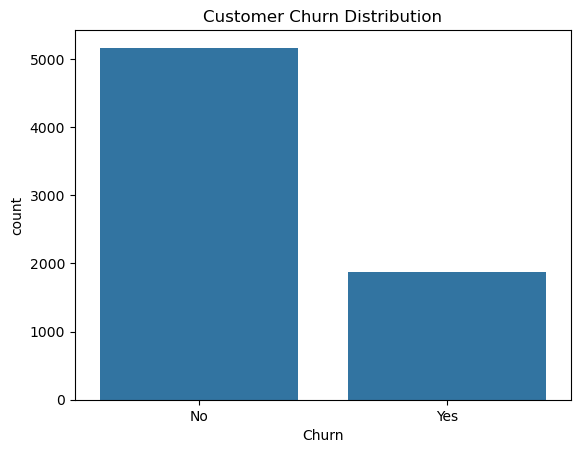

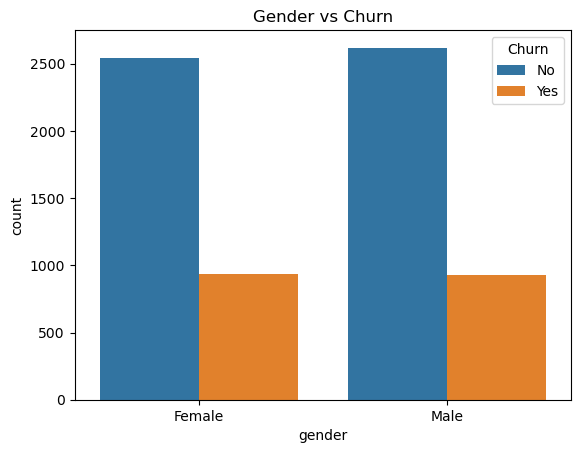

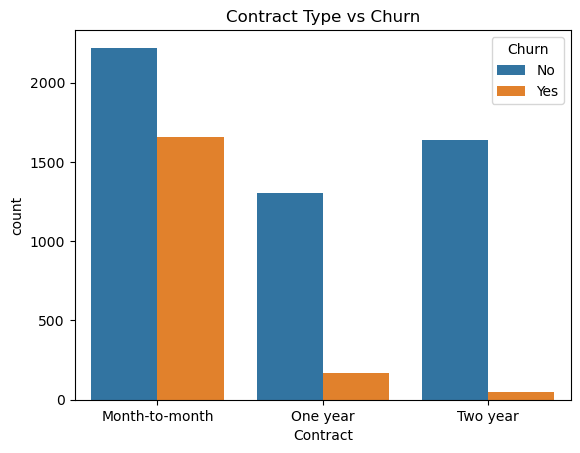

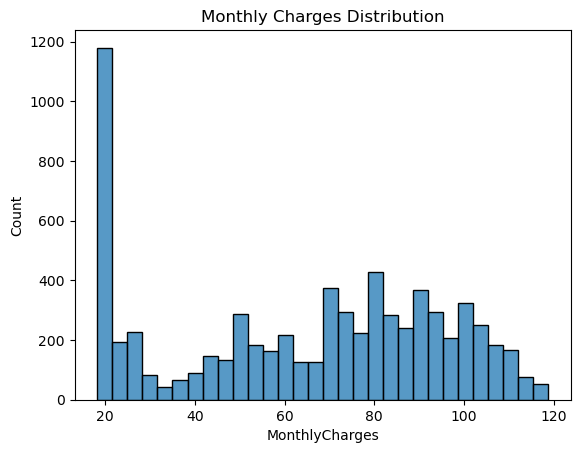

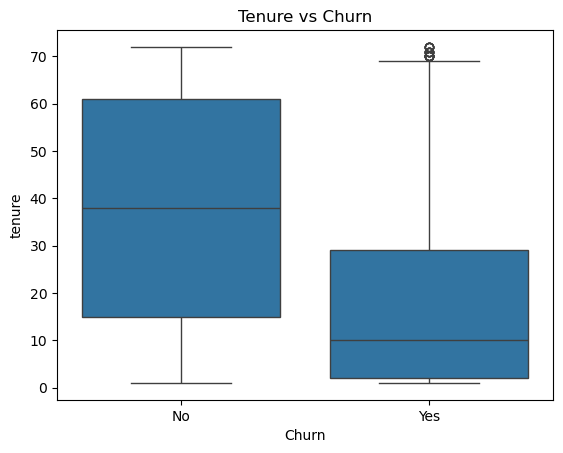

Accuracy: 0.7917555081734187

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.64      0.49      0.55       374

    accuracy                           0.79      1407
   macro avg       0.74      0.69      0.71      1407
weighted avg       0.78      0.79      0.78      1407



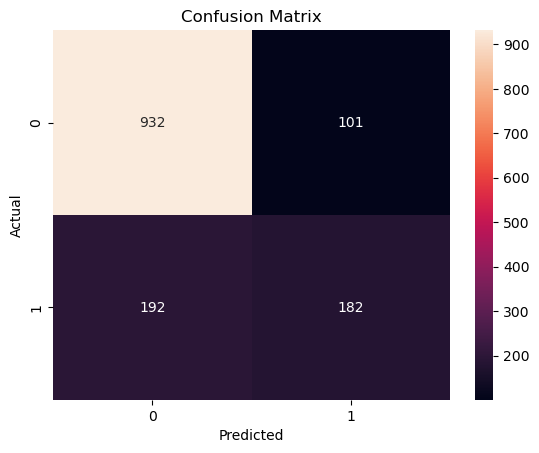

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# -----------------------------
# 1 Load Dataset
# -----------------------------

path = r"C:\Users\Anshika\.cache\kagglehub\datasets\blastchar\telco-customer-churn\versions\1\WA_Fn-UseC_-Telco-Customer-Churn.csv"

df = pd.read_csv(path)

print("Dataset Shape:", df.shape)
print(df.head())

# -----------------------------
# 2 Data Cleaning
# -----------------------------

# Convert TotalCharges to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Remove missing values
df.dropna(inplace=True)

# Remove customerID column
df.drop('customerID', axis=1, inplace=True)

# -----------------------------
# 3 Data Visualization
# -----------------------------

# Churn distribution
plt.figure()
sns.countplot(x='Churn', data=df)
plt.title("Customer Churn Distribution")
plt.show()

# Gender vs churn
plt.figure()
sns.countplot(x='gender', hue='Churn', data=df)
plt.title("Gender vs Churn")
plt.show()

# Contract type vs churn
plt.figure()
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title("Contract Type vs Churn")
plt.show()

# Monthly charges distribution
plt.figure()
sns.histplot(df['MonthlyCharges'], bins=30)
plt.title("Monthly Charges Distribution")
plt.show()

# Tenure vs churn
plt.figure()
sns.boxplot(x='Churn', y='tenure', data=df)
plt.title("Tenure vs Churn")
plt.show()

# -----------------------------
# 4 Encode Categorical Data
# -----------------------------

le = LabelEncoder()

for column in df.columns:
    if df[column].dtype == 'object':
        df[column] = le.fit_transform(df[column])

# -----------------------------
# 5 Feature Scaling
# -----------------------------

scaler = StandardScaler()

X = df.drop('Churn', axis=1)
y = df['Churn']

X_scaled = scaler.fit_transform(X)

# -----------------------------
# 6 Train Test Split
# -----------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# -----------------------------
# 7 Train Model
# -----------------------------

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

# -----------------------------
# 8 Prediction
# -----------------------------

pred = model.predict(X_test)

# -----------------------------
# 9 Evaluation
# -----------------------------

print("Accuracy:", accuracy_score(y_test, pred))

print("\nClassification Report:")
print(classification_report(y_test, pred))

cm = confusion_matrix(y_test, pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()